#Studying Habits and Academic Performance Analysis

# Introduction
This notebook presents a comprehensive analysis of the factors affecting academic performance based on the students' survey data collected through Google Forms. The primary goal is to explore the relationships between quantitative variables such as weekly studying hours, sleep duration, and GPA. Also, qualitative behaviors like lecture attendance, exam preparation timing, preferred studying techniques and employment status.

By cleaning the data, addressing outliers, and utilizing various visualization techniques, the aim to uncover trends and patterns that characterize high achieving students and understand the balance between academic commitments and lifestyle factors.

# Hypothesis Claim
H0: There is no correlation between study hours and GPA.

H1: There is a positive correlation between study hours and GPA.

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#Loading the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving studying_habits_and_academic_performance_survey.csv to studying_habits_and_academic_performance_survey (2).csv


In [ ]:
df = pd.read_csv("studying_habits_and_academic_performance_survey.csv")
df.head(20)

,Timestamp,How many hours do you study per week on average?,What is your GPA? (Anonymous),How often do you attend your lectures?,Do you study regularly (daily or almost daily)?,When do you usually start studying before an exam?,What is your preferred study method?,How many hours do you sleep per day?,Do you currently have a job?
0,2026/04/04 9:22:12 PM GMT+2,15.0,2.85,Always (almost every lecture),Often (4–5 days a week),A few days before,Reading and summarizing;Solving problems/pract...,6.0,Yes (part-time)
1,2026/04/04 9:24:26 PM GMT+2,9.0,3.23,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,Reading and summarizing;Solving problems/pract...,5.0,Yes (part-time)
2,2026/04/04 9:26:04 PM GMT+2,20.0,3.42,Always (almost every lecture),"Yes, daily",1–2 weeks before,Solving problems/practice questions;Watching v...,7.0,No
3,2026/04/04 9:27:09 PM GMT+2,6.0,2.32,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,Reading and summarizing;Solving problems/pract...,6.0,No
4,2026/04/04 9:34:23 PM GMT+2,5.0,3.40,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,Reading and summarizing;Watching videos/online...,8.0,Yes (part-time)
5,2026/04/04 9:35:15 PM GMT+2,5.0,3.00,Often (more than 75%),Sometimes (2–3 days a week),The day before,Reading and summarizing;Solving problems/pract...,12.0,No
6,2026/04/04 9:36:42 PM GMT+2,10.0,2.00,Sometimes (around 50%),Sometimes (2–3 days a week),A few days before,Reading and summarizing,9.0,Yes (part-time)
7,2026/04/04 9:36:50 PM GMT+2,7.0,2.80,Sometimes (around 50%),Often (4–5 days a week),A few days before,Solving problems/practice questions,8.0,No
8,2026/04/04 9:37:01 PM GMT+2,25.0,3.70,Often (more than 75%),Sometimes (2–3 days a week),1–2 weeks before,Reading and summarizing;Solving problems/pract...,8.0,Yes (part-time)
9,2026/04/04 9:37:11 PM GMT+2,0.0,2.01,Sometimes (around 50%),Rarely,A few days before,Reading and summarizing;Solving problems/pract...,10.0,No


#Inspecting the dataset

In [ ]:
df.shape

(100, 9)

The dataset has 100 rows/records and 9 columns/features. This means that the sample size is 100. We managed to collect 100 records from the population forming a sample size of 100.

In [ ]:
df.columns

Index(['Timestamp', 'How many hours do you study per week on average?',
       'What is your GPA? (Anonymous)',
       'How often do you attend your lectures?',
       'Do you study regularly (daily or almost daily)?',
       'When do you usually start studying before an exam?',
       'What is your preferred study method?',
       'How many hours do you sleep per day?', 'Do you currently have a job?'],
      dtype='object')

The column names are the questions asked in the Google Form, therefore it needs to be changed to simpler variables so dealing with the data becomes easier.

In [ ]:
df.rename(columns={
    'Timestamp': 'time',
    'How many hours do you study per week on average?': 'studyhrs/week',
    'What is your GPA? (Anonymous)': 'gpa',
    'How often do you attend your lectures?': 'lecattendance',
    'Do you study regularly (daily or almost daily)?': 'studyfreq',
    'When do you usually start studying before an exam?': 'studybefexam',
    'What is your preferred study method?': 'prefmethod',
    'How many hours do you sleep per day?': 'sleephrs',
    'Do you currently have a job?': 'job'
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           100 non-null    object 
 1   studyhrs/week  100 non-null    float64
 2   gpa            100 non-null    float64
 3   lecattendance  100 non-null    object 
 4   studyfreq      100 non-null    object 
 5   studybefexam   100 non-null    object 
 6   prefmethod     100 non-null    object 
 7   sleephrs       100 non-null    float64
 8   job            100 non-null    object 
dtypes: float64(3), object(6)
memory usage: 7.2+ KB


The dataset has 3 columns representing quantitative variables with the data type of float. These columns are studyhrs/week, gpa and sleephrs. Whereas the other 6 columns represent categorical variables with the data type of object. These columns are time, lecattendance, studyfreq, studybefexam,prefmethod and job.

In [ ]:
df.isna().sum()

,0
time,0
studyhrs/week,0
gpa,0
lecattendance,0
studyfreq,0
studybefexam,0
prefmethod,0
sleephrs,0
job,0


No missing or null values were found in the dataset.

#Cleaning the dataset

In [ ]:
df.drop('time', axis=1, inplace=True)

The timestamp column is not relevant for statistical analysis and therefore was removed.

In [ ]:
skip_cols = ['studyhrs/week', 'gpa', 'sleephrs']

for col in df.columns:
    if col not in skip_cols:
        print(col,df[col].unique())

lecattendance ['Always (almost every lecture)' 'Often (more than 75%)'
 'Sometimes (around 50%)' 'Rarely (less than 25%)' 'Never']
studyfreq ['Often (4–5 days a week)' 'Sometimes (2–3 days a week)' 'Yes, daily'
 'Rarely' 'Never']
studybefexam ['A few days before' '1–2 weeks before' 'The day before'
 'More than 2 weeks before']
prefmethod ['Reading and summarizing;Solving problems/practice questions;Group study;Memorization only'
 'Reading and summarizing;Solving problems/practice questions;Watching videos/online lectures'
 'Solving problems/practice questions;Watching videos/online lectures'
 'Reading and summarizing;Solving problems/practice questions;Memorization only'
 'Reading and summarizing;Watching videos/online lectures'
 'Reading and summarizing' 'Solving problems/practice questions'
 'Reading and summarizing;Watching videos/online lectures;Group study'
 'Reading and summarizing;Solving problems/practice questions'
 'Watching videos/online lectures'
 'Solving problems/practice

This loop shows us how many classes were present per each categorical column. The prefmethod column offers multiple selections in the same variable. Each subvariable inside the variable prefmethod needs to be binary encoded, so it is easier to deal with each subvariable as an independent variable that has its own column in the datset and has its values per records.

In [ ]:
df.columns

Index(['studyhrs/week', 'gpa', 'lecattendance', 'studyfreq', 'studybefexam',
       'prefmethod', 'sleephrs', 'job'],
      dtype='object')

In [ ]:
df = df.join(df['prefmethod'].str.get_dummies(sep=';'))
df = df.drop(columns=['prefmethod'])

In [ ]:
df.head(20)

,studyhrs/week,gpa,lecattendance,studyfreq,studybefexam,sleephrs,job,Group study,Memorization only,Reading and summarizing,Solving problems/practice questions,Watching videos/online lectures
0,15.0,2.85,Always (almost every lecture),Often (4–5 days a week),A few days before,6.0,Yes (part-time),1,1,1,1,0
1,9.0,3.23,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,5.0,Yes (part-time),0,0,1,1,1
2,20.0,3.42,Always (almost every lecture),"Yes, daily",1–2 weeks before,7.0,No,0,0,0,1,1
3,6.0,2.32,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,6.0,No,0,1,1,1,0
4,5.0,3.40,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,8.0,Yes (part-time),0,0,1,0,1
5,5.0,3.00,Often (more than 75%),Sometimes (2–3 days a week),The day before,12.0,No,0,0,1,1,1
6,10.0,2.00,Sometimes (around 50%),Sometimes (2–3 days a week),A few days before,9.0,Yes (part-time),0,0,1,0,0
7,7.0,2.80,Sometimes (around 50%),Often (4–5 days a week),A few days before,8.0,No,0,0,0,1,0
8,25.0,3.70,Often (more than 75%),Sometimes (2–3 days a week),1–2 weeks before,8.0,Yes (part-time),0,0,1,1,1
9,0.0,2.01,Sometimes (around 50%),Rarely,A few days before,10.0,No,0,0,1,1,1


In [ ]:
df.columns

Index(['studyhrs/week', 'gpa', 'lecattendance', 'studyfreq', 'studybefexam',
       'sleephrs', 'job', 'Group study', 'Memorization only',
       'Reading and summarizing', 'Solving problems/practice questions',
       'Watching videos/online lectures'],
      dtype='object')

In [ ]:
df.shape

(100, 12)

After encoding the prefmethod column the dataset has 12 columns/features with the subvariables of the previously prefmethod column binary encoded.

#Quantitative Analysis

Quantitative analysis is performed on the numerical columns and they are studyhtrs/week, sleephrs and gpa.

In [ ]:
df[['studyhrs/week','sleephrs','gpa']].describe()

,studyhrs/week,sleephrs,gpa
count,100.000000,100.000000,100.000000
mean,12.655000,7.235000,14.122200
std,11.335939,1.811098,110.797063
min,0.000000,4.000000,1.800000
25%,6.000000,6.000000,2.737500
50%,10.000000,7.000000,3.100000
75%,15.000000,8.000000,3.442500
max,60.000000,12.000000,1111.000000


In [ ]:
numerical = ['studyhrs/week','gpa','sleephrs']

for column in numerical:
    print(f"{column}:")
    print(f"  Mean: {df[column].mean():.2f}")
    print(f"  Standard Deviation: {df[column].std():.2f}")
    print(f"  Minimum: {df[column].min():.2f}")
    print(f"  Maximum: {df[column].max():.2f}")

studyhrs/week:
  Mean: 12.65
  Standard Deviation: 11.34
  Minimum: 0.00
  Maximum: 60.00
gpa:
  Mean: 14.12
  Standard Deviation: 110.80
  Minimum: 1.80
  Maximum: 1111.00
sleephrs:
  Mean: 7.24
  Standard Deviation: 1.81
  Minimum: 4.00
  Maximum: 12.00


* The value that represents the studying hours per week for the collected data is 12.65 hours with the standard deviation of 11.34 hours, a maximum of 60 hours and a minimum of 0 hours.
* The value that represents the GPA is 14.12 which raises concern about outliers found in the GPA data. It has a standard deviation of 110.8, a maximum of 1111 and a minimum of 1.8.

Note: The maximum value for GPA is found to be 1111 which is irrelevant to the GPA variable.

* The value that represents the sleep hours is 7.24 hours with standard deviation of 1.81 hours, a maximum of 12 hours and a minimum of 4 hours.





##Checking for Outliers in the quantitative variables
The boxplot is the most relevant method to check easily for outliers found in the dataset through visualization.

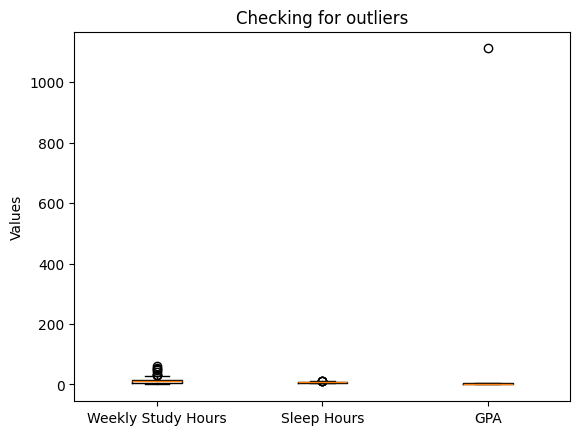

In [ ]:
plt.boxplot(df[['studyhrs/week','sleephrs','gpa']], tick_labels=['Weekly Study Hours', 'Sleep Hours', 'GPA'])
plt.title('Checking for outliers')
plt.ylabel('Values')
plt.show()

There is a clear outlier found in the GPA, it could be due to false data entry.

In [ ]:
df['gpa'].sort_values(ascending=False).head()

,gpa
42,1111.00
58,4.00
85,4.00
37,3.94
82,3.93


In [ ]:
mean_gpa = df.loc[df['gpa'] < 4.01, 'gpa'].mean()
df.loc[df['gpa'] > 4.01, 'gpa'] = mean_gpa

The outlier value of the GPA was replaced by the mean value of the other GPA values without including the outlier's GPA value. This was done instead of deleting the record due to the small number of records in this dataset. So, every record is needed for the analysis.

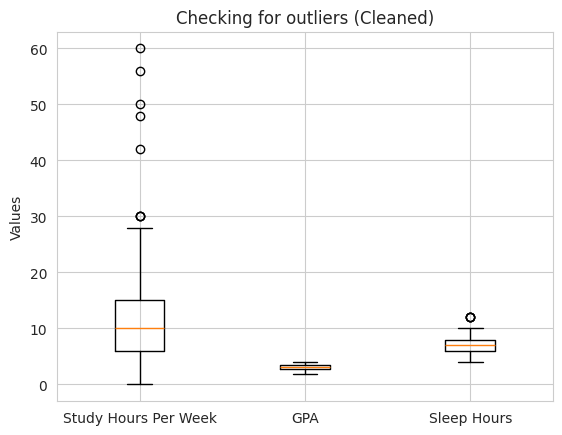

In [ ]:
plt.boxplot(df[['studyhrs/week','gpa','sleephrs']], tick_labels=['Study Hours Per Week','GPA','Sleep Hours'])
plt.title("Checking for outliers (Cleaned)")
plt.ylabel('Values')
plt.show()

Some outliers are detected for the studyhrs/week and sleephrs variables but they are not extreme outliers and the analysis can be conducted normally without their removal.

In [ ]:
numerical = ['studyhrs/week','gpa','sleephrs']

for column in numerical:
    print(f"{column}:")
    print(f"  Mean: {df[column].mean():.2f}")
    print(f"  Standard Deviation: {df[column].std():.2f}")
    print(f"  Minimum: {df[column].min():.2f}")
    print(f"  Maximum: {df[column].max():.2f}")

studyhrs/week:
  Mean: 12.65
  Standard Deviation: 11.34
  Minimum: 0.00
  Maximum: 60.00
gpa:
  Mean: 3.04
  Standard Deviation: 0.54
  Minimum: 1.80
  Maximum: 4.00
sleephrs:
  Mean: 7.24
  Standard Deviation: 1.81
  Minimum: 4.00
  Maximum: 12.00


Now, the mean value for the GPA makes more sense and represents the GPA data correctly.

##Qualitative Variables Plots

Study Hours Per Week

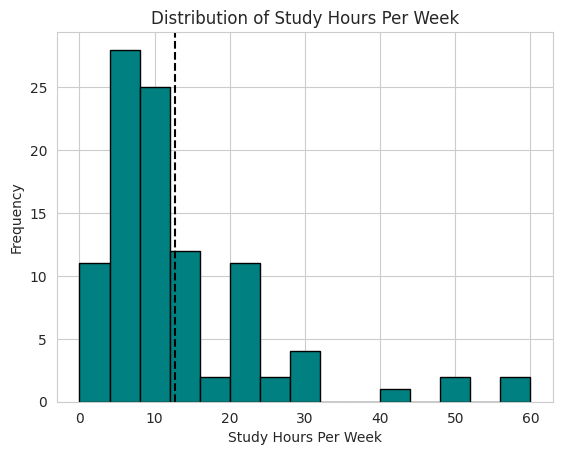

In [ ]:
plt.hist(df['studyhrs/week'], bins=15, color='teal', edgecolor='black')
plt.axvline(df['studyhrs/week'].mean(), color='black', linestyle='dashed')
plt.title("Distribution of Study Hours Per Week")
plt.xlabel("Study Hours Per Week")
plt.ylabel("Frequency")
plt.show()

This plot represents the distribution of Study Hours Per Week where the curve appears to be right-skewed with the black-dashed line representing the mean of the Study Hours Per Week Values. The outlier values that were shown by the boxplot are clearly visible in this plot. These outliers move the mean value towards them making the mean value slightly irrelevant to be a value that represents the data.

A discontinuity is present between 30 and 40 hours.

GPA

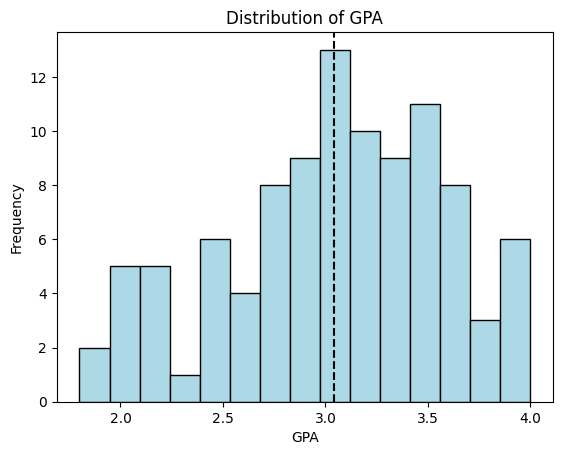

In [ ]:
plt.hist(df['gpa'], bins=15, color='lightblue', edgecolor='black' )
plt.axvline(df['gpa'].mean(), color='black', linestyle='dashed')
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

This plot represents the distribution of GPA. After replacing the extreme outlier (1111.0) with the mean of the remaining data, the distribution shows that most students have a GPA between 2.5 and 3.5. The black-dashed line represents the mean GPA of approximately 3.04. Unlike the study hours, this distribution appears more bell-shaped, though slightly constrained by the typical GPA range (0.0 to 4.0).

Sleep Hours

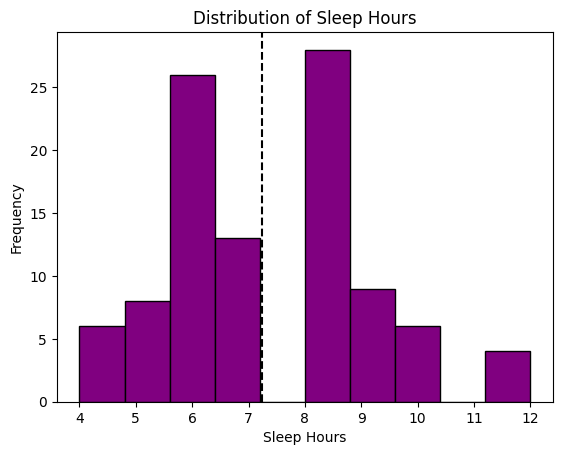

In [ ]:
plt.hist(df['sleephrs'], bins=10, color='purple', edgecolor='black')
plt.axvline(df['sleephrs'].mean(), color='black', linestyle='dashed')
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()

This plot represents the distribution of Sleep Hours. The data is centered around a mean of 7.24 hours (indicated by the black-dashed line), with most students reporting between 6 and 8 hours of sleep. The distribution appears relatively symmetric, though there are minor peaks at 6 and 8 hours, likely due to respondents rounding their answers to the nearest integer. The outliers previously identified by the boxplot is visible at the 10-12 hour mark.

##Inspecting relations between quantitative variables

1.Sleep Hours vs GPA

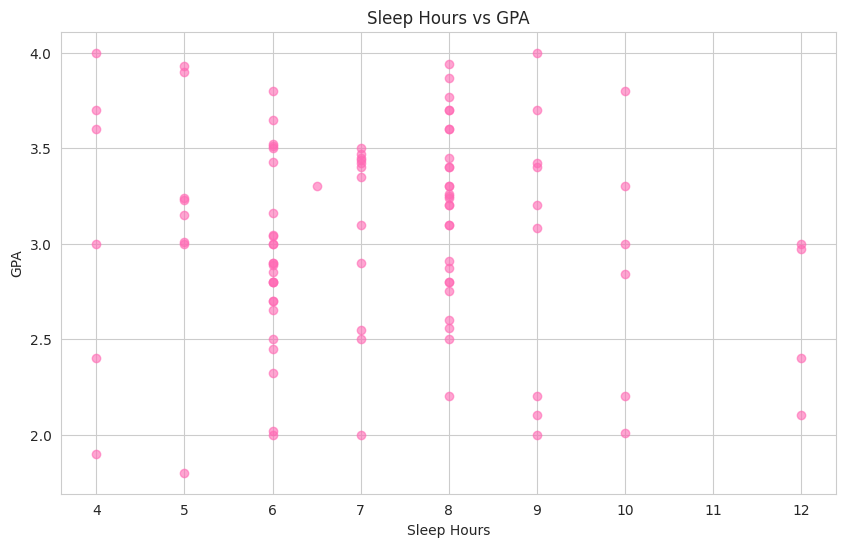

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(data = df, x ='sleephrs', y='gpa', color='hotpink', alpha=0.6)
plt.title("Sleep Hours vs GPA")
plt.xlabel('Sleep Hours')
plt.ylabel('GPA')
plt.show()

This scatter plot between sleep hours and GPA does not show a clear pattern or trend. The data points are widely dispersed, indicating that students with both high and low GPAs appear across different sleep durations. Therefore, there is no strong linear correlation between sleep hours and GPA in the dataset.

2.Study Hours Per Week vs GPA

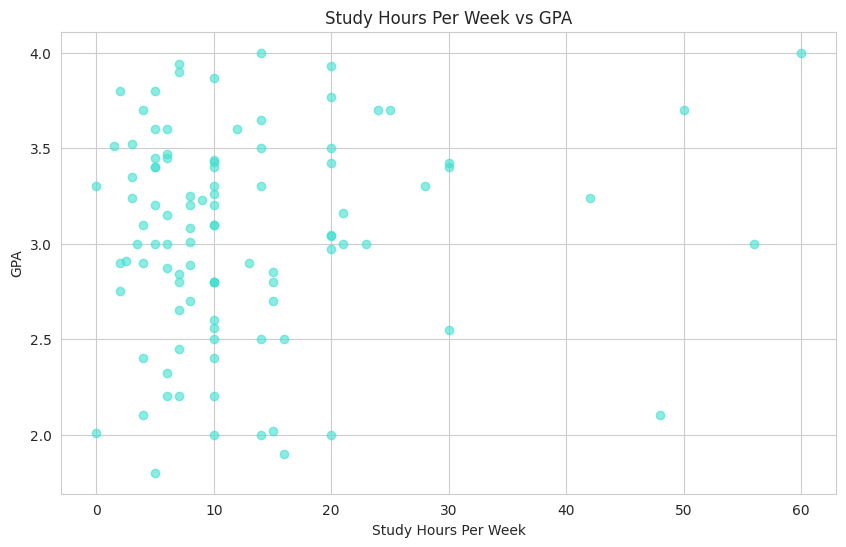

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(data = df, x ='studyhrs/week', y='gpa', color='turquoise', alpha=0.6)
plt.title("Study Hours Per Week vs GPA")
plt.xlabel('Study Hours Per Week')
plt.ylabel('GPA')
plt.show()

This scatter plot between study hours per week and GPA shows a weak relationship between the two variables. Most observations are concentrated between 5 and 15 study hours, with GPA values widely distributed within this range. Due to this clustering of data points, a heat map will be used to better visualize the density of observations and identify any potential patterns that may not be clearly visible in the scatter plot.

Text(0, 0.5, 'GPA')

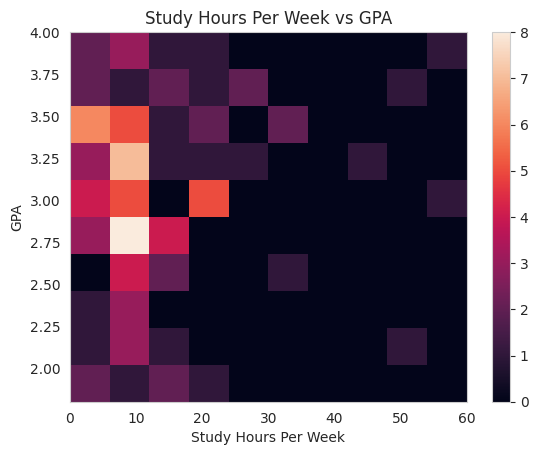

In [ ]:
plt.hist2d(data = df, x ='studyhrs/week', y='gpa')
plt.colorbar()
plt.title("Study Hours Per Week vs GPA")
plt.xlabel('Study Hours Per Week')
plt.ylabel('GPA')

The heat map of study hours per week and GPA shows that most students study between 5 and 12 hours per week. The visualization does not reveal a strong linear relationship between study hours and GPA, as high and low GPA values appear across similar study hours ranges.

3.Study Hours Per Week vs Sleep Hours

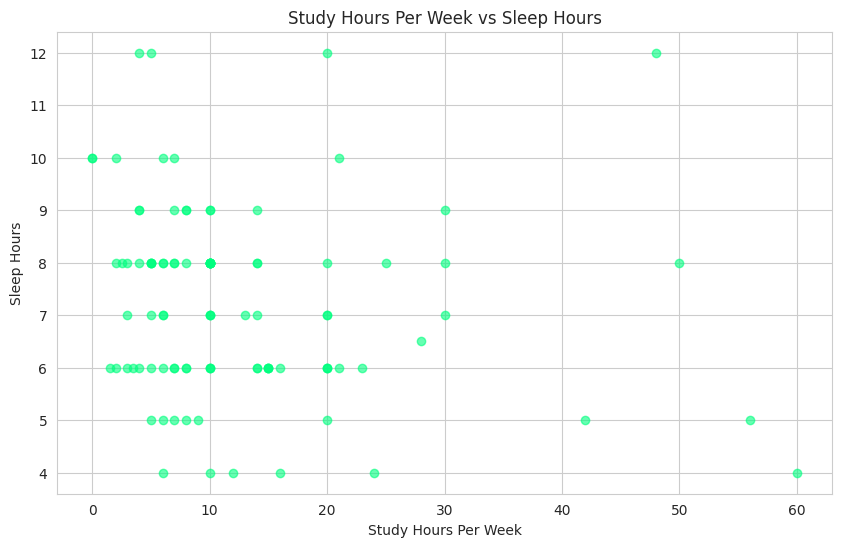

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(data = df, x ='studyhrs/week', y='sleephrs', color='springgreen', alpha=0.6)
plt.title("Study Hours Per Week vs Sleep Hours")
plt.xlabel('Study Hours Per Week')
plt.ylabel('Sleep Hours')
plt.show()

This scatter plot between study hours per week and sleep hours shows no clear linear relationship. Sleep duration varies widely across all levels of study hours, indicating that the amount of time students spend studying does not affect how many hours they sleep.

In [ ]:
df[['studyhrs/week','gpa','sleephrs']].corr()

,studyhrs/week,gpa,sleephrs
studyhrs/week,1.000000,0.110220,-0.149023
gpa,0.110220,1.000000,-0.082667
sleephrs,-0.149023,-0.082667,1.000000


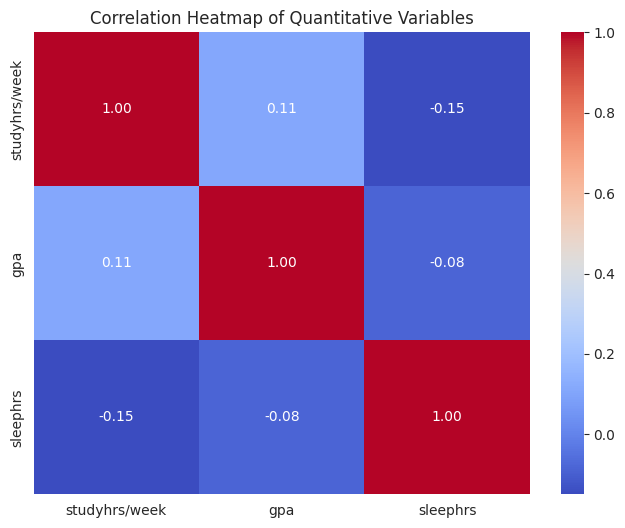

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['studyhrs/week', 'gpa', 'sleephrs']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Quantitative Variables')
plt.show()

The correlation analysis between weekly study hours, GPA, and sleep hours revealed no strong linear relationships due to the small sample size. The correlation coefficient between study hours and GPA was close to zero, suggesting that increased study time alone does not necessarily correspond to higher academic performance among respondents. If a large sample was taken form the population, some correlations might be present. Logically, Studying Hours per Week and GPA, Sleeping Hours and GPA and Sleeping Hours and Studying Hours Per Week Should be somehow correlated but since the sample size relative to the population is small, correlations can't be inferred.

# Qualitative Analysis

##Lecture Attendance

/tmp/ipykernel_1346/3185075842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='lecattendance', order=df['lecattendance'].value_counts().index, palette='viridis')


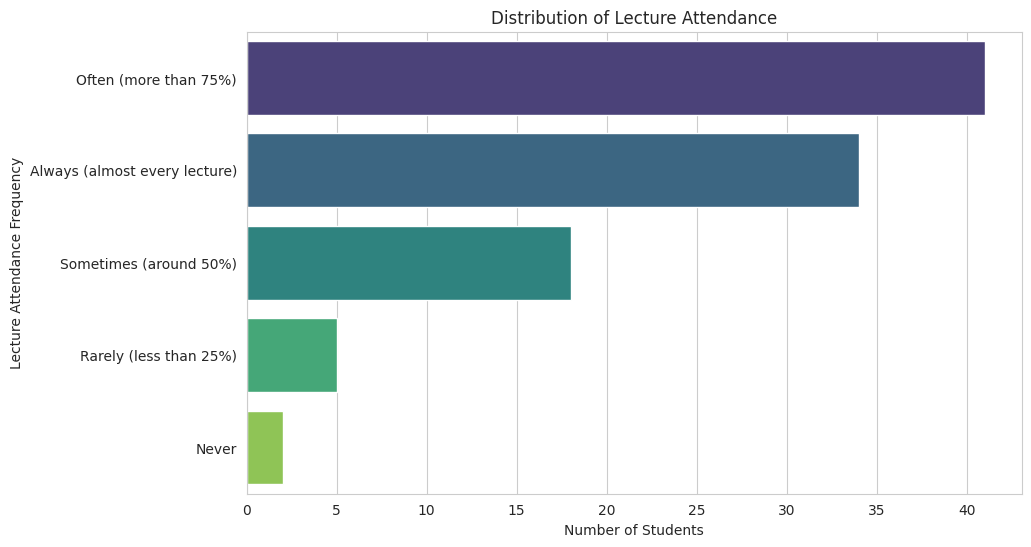

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='lecattendance', order=df['lecattendance'].value_counts().index, palette='viridis')
plt.title('Distribution of Lecture Attendance')
plt.xlabel('Number of Students')
plt.ylabel('Lecture Attendance Frequency')
plt.show()

The distribution of lecture attendance shows that most students attend lectures regularly. The majority of students reported attending lectures often (more than 75%) or always (almost every lecture). Only a small number of students reported rarely or never attending lectures, indicating generally high lecture attendance among the surveyed students.

## Study Frequency

/tmp/ipykernel_1346/520080219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='studyfreq', order=df['studyfreq'].value_counts().index, palette='magma')


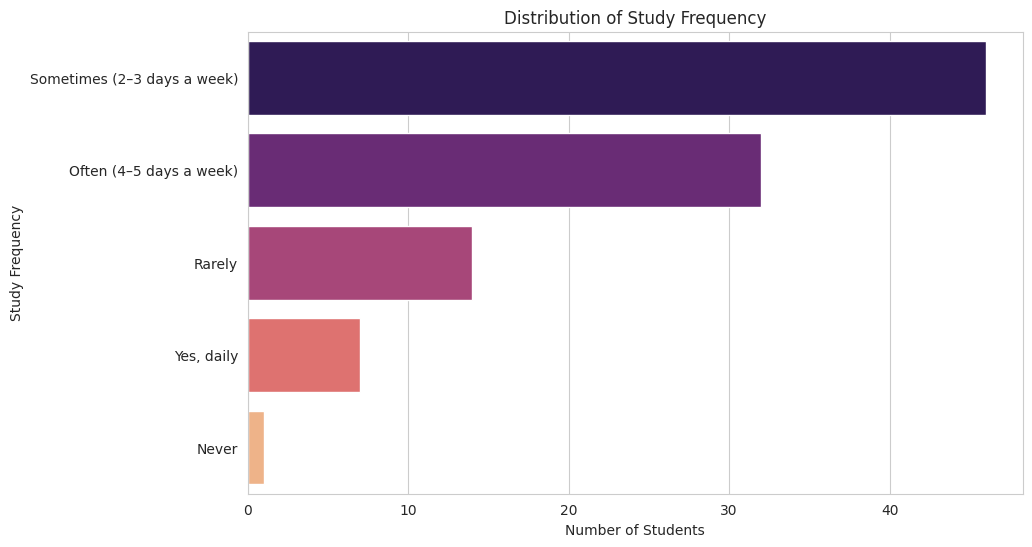

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='studyfreq', order=df['studyfreq'].value_counts().index, palette='magma')
plt.title('Distribution of Study Frequency')
plt.xlabel('Number of Students')
plt.ylabel('Study Frequency')
plt.show()

The distribution of study frequency indicates that most students study between two and five days per week. The largest group reported studying Sometimes (2–3 days per week), followed by those who study often (4–5 days per week). Only a small number of students study daily, while very few reported rarely or never studying.

## Study Time Before Exam

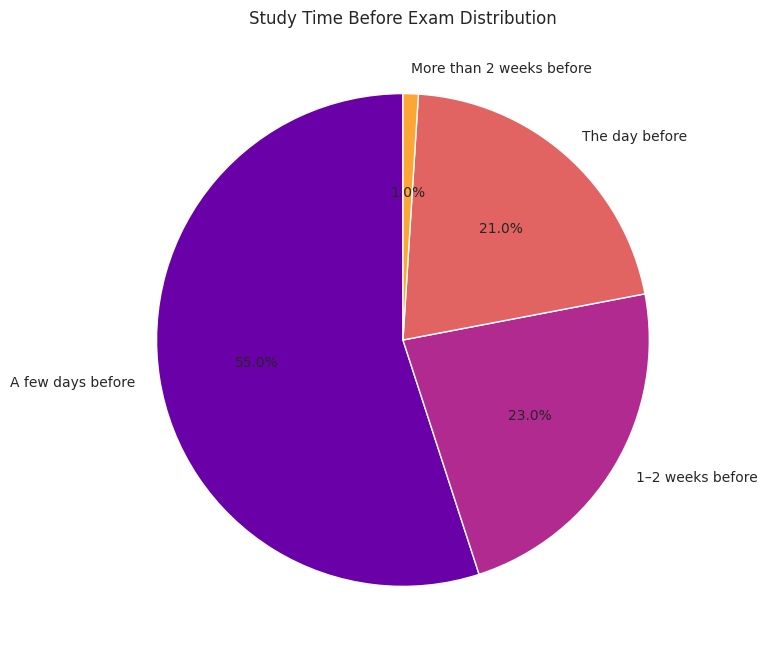

In [ ]:
plt.figure(figsize=(8,8))
counts = df['studybefexam'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('plasma', len(counts)), startangle=90)
plt.title('Study Time Before Exam Distribution')
plt.show()

This pie chart illustrates that the majority of students (55%) begin studying a few days before the exam. A smaller proportion of students start studying one to two weeks before the exam (23%), while 21% study only the day before the exam. Very few students (1%) begin studying more than two weeks in advance, indicating that the surveyed students are not familiar with long term exam preparation.

## Job Status

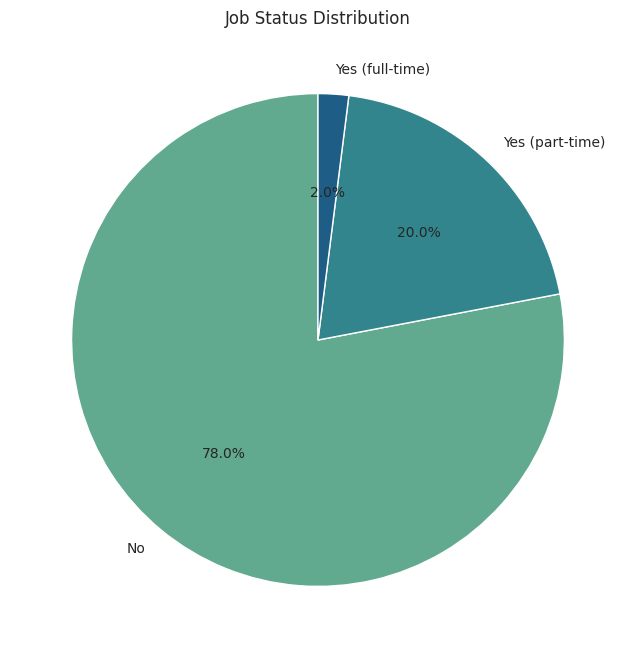

In [ ]:
plt.figure(figsize=(8,8))
counts = df['job'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('crest', len(counts)), startangle=90,)
plt.title('Job Status Distribution')
plt.show()

This pie chart illustrates the distribution of job status among students. The majority of students (78%) reported not having a job. A smaller proportion of students (20%) work part-time, while only a very small percentage (2%) are employed full-time. This indicates that most students focus primarily on their academic activities rather than employment.

##Preferred Study Methods

Since students could select multiple study methods based on the format of the Google Form, we analyze the frequency of each method independently based on the binary encoded columns that was created during the data cleaning phase.

In [ ]:
study_methods = [
    'Group study',
    'Memorization only',
    'Reading and summarizing',
    'Solving problems/practice questions',
    'Watching videos/online lectures'
]
method_counts = df[study_methods].sum().sort_values(ascending=False)

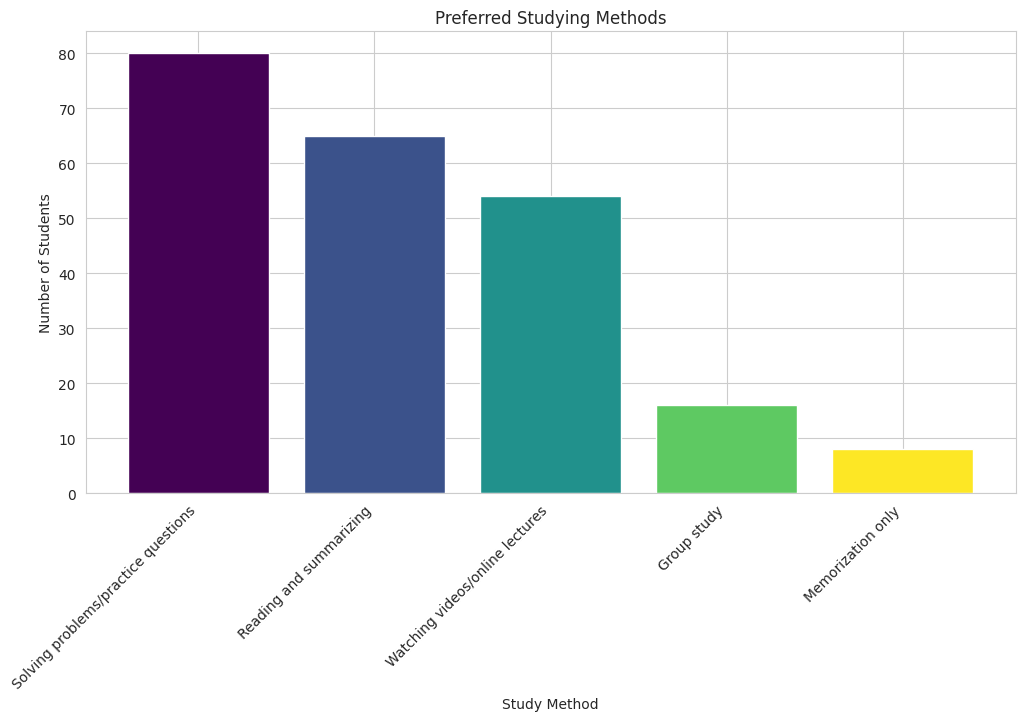

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(method_counts.index, method_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(method_counts))))
plt.title('Preferred Studying Methods')
plt.xlabel('Study Method')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.show()

The distribution of preferred study methods shows that solving problems or practicing questions is the most popular method among students, followed by reading and summarizing. Watching online lectures is also commonly used. In contrast, group study and memorization-only methods are less preferred, suggesting that most students favor active and comprehension-based study strategies.

#Conclusion

* This analysis explored the relationship between students' studying habits and academic performance using survey data. Several quantitative and categorical variables were examined, including weekly study hours, sleep duration, attendance, and preferred studying methods.

* Exploratory visualizations such as histograms, scatter plots, and pie charts were used to understand the distribution of the variables and identify potential patterns. The scatter plots and correlation analysis between key quantitative variables such as study hours, sleep hours, and GPA revealed no strong linear relationships within the dataset. The heatmap visualization confirmed that the correlation coefficients between these variables were close to zero.

* These findings suggest that academic performance cannot be explained by a single factor such as study hours or sleep duration alone. Instead, academic success is likely influenced by a combination of factors including study techniques, consistency, motivation, and external circumstances.

* It is also important to note that the dataset is based on a limited sample collected through a survey, which may not fully represent the broader student population. Therefore, the absence of strong correlations in this analysis does not necessarily imply that such relationships do not exist in the general population.

* Future studies with larger and more diverse datasets, along with more advanced statistical techniques such as regression analysis or hypothesis testing, could provide deeper insights into the factors that influence students' academic performance.